# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam
## NAMA : Said Muhammad Ridho Oktafiandra


## NIM  : 4222301066


## Robotika C Pagi (6)

Notebook ini akan mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Kita akan membandingkan berbagai jenis *gait* untuk *quadruped* (Trot, Crawl) dan merancang *Tripod Gait* untuk *Hexapod*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("Environment siap!")

Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

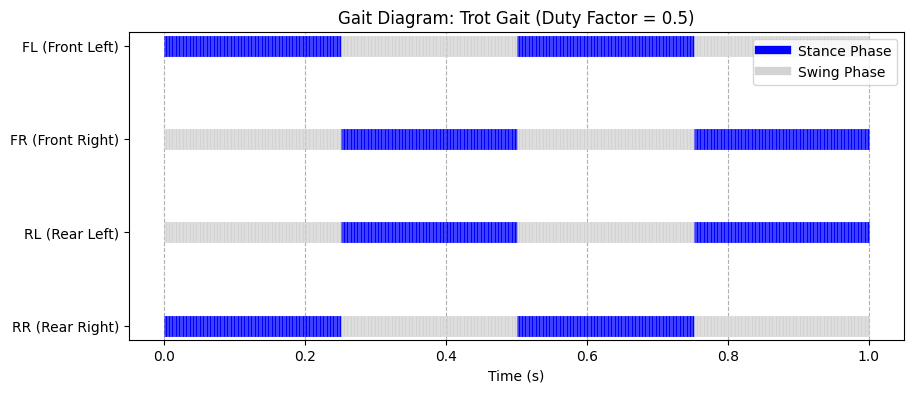

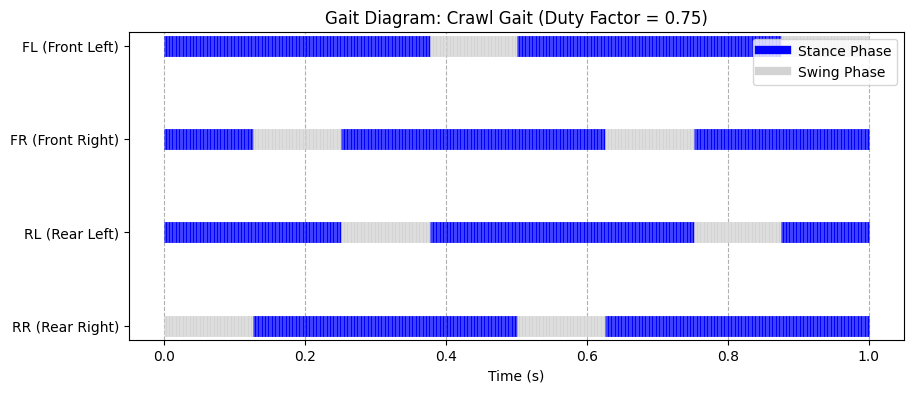

In [2]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')

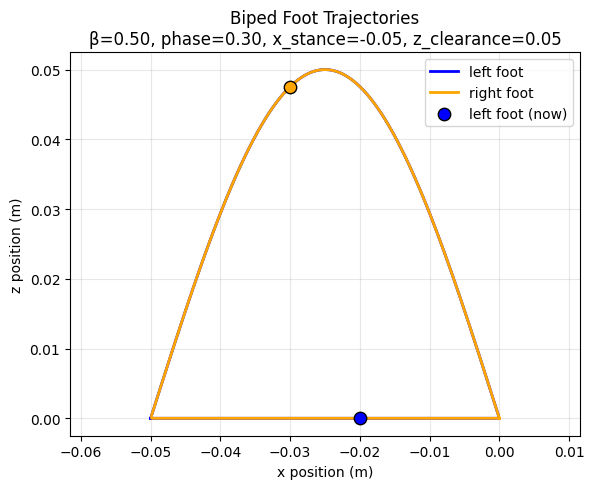

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

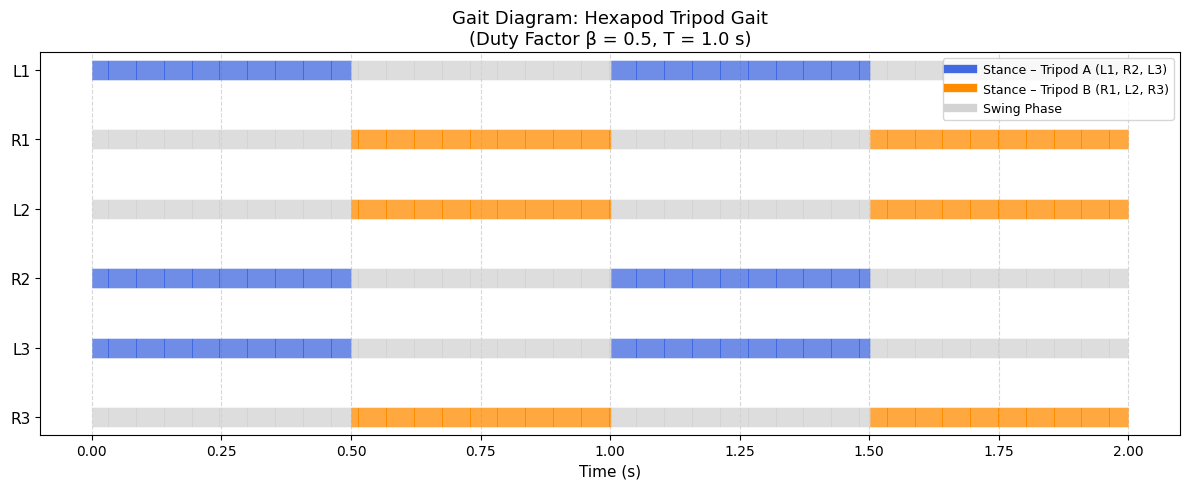

[Stability Check] Persentase waktu dengan ≥3 kaki di tanah: 100.0%
  ✓ Robot SELALU stabil secara statis (static stability terpenuhi 100%).


In [4]:
class HexapodGaitScheduler:
    """
    Gait Scheduler untuk robot Hexapod (6 kaki).
    Mendukung Tripod Gait di mana dua segitiga kaki bergantian stance/swing.

    Segitiga 1 (Tripod A): L1, R2, L3  -> bergerak bersamaan (offset = 0.0)
    Segitiga 2 (Tripod B): R1, L2, R3  -> bergerak bersamaan (offset = 0.5)
    """

    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3']

    def get_phase(self, t, offset):
        """Menghitung fase dari 0.0 hingga 1.0 berdasarkan waktu dan offset."""
        return ((t / self.T) + offset) % 1.0

    def verify_static_stability(self, duty_factor, offsets, n_check=200):
        """
        Verifikasi Static Stability Margin (SSM).
        Pada setiap time step, minimal 3 kaki harus berada di tanah (stance)
        agar robot memiliki fondasi segitiga yang stabil.
        Mengembalikan persentase waktu robot dalam keadaan stabil.
        """
        time_steps = np.linspace(0, self.T, n_check)
        stable_count = 0
        for t in time_steps:
            phases = [self.get_phase(t, off) for off in offsets]
            stance_count = sum(1 for ph in phases if ph < duty_factor)
            if stance_count >= 3:
                stable_count += 1
        stability_pct = (stable_count / n_check) * 100
        return stability_pct

    def plot_gait_diagram(self, duty_factor, offsets, title):
        """Plot diagram Gantt gait untuk hexapod."""
        time_steps = np.linspace(0, 2 * self.T, 1000)  # 2 siklus

        n_legs = len(self.legs)
        colors_tripod = {
            'L1': 'royalblue', 'R2': 'royalblue', 'L3': 'royalblue',   # Tripod A
            'R1': 'darkorange', 'L2': 'darkorange', 'R3': 'darkorange'  # Tripod B
        }

        fig, ax = plt.subplots(figsize=(12, 5))

        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = np.where(phases < duty_factor, 1, 0)
            y_pos = n_legs - 1 - i
            c = colors_tripod[leg]

            for t_idx in range(len(time_steps) - 1):
                color = c if stance[t_idx] == 1 else 'lightgray'
                ax.plot([time_steps[t_idx], time_steps[t_idx+1]],
                        [y_pos, y_pos], color=color, lw=14, solid_capstyle='butt')

        ax.set_yticks(range(n_legs))
        ax.set_yticklabels(self.legs[::-1], fontsize=11)
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_title(f'Gait Diagram: {title}\n'
                     f'(Duty Factor β = {duty_factor}, T = {self.T} s)', fontsize=13)
        ax.grid(axis='x', linestyle='--', alpha=0.5)

        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='royalblue',  lw=6, label='Stance – Tripod A (L1, R2, L3)'),
            Line2D([0], [0], color='darkorange', lw=6, label='Stance – Tripod B (R1, L2, R3)'),
            Line2D([0], [0], color='lightgray',  lw=6, label='Swing Phase'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
        plt.tight_layout()
        plt.show()

        # --- Verifikasi stabilitas ---
        ssm = self.verify_static_stability(duty_factor, offsets)
        print(f"[Stability Check] Persentase waktu dengan ≥3 kaki di tanah: {ssm:.1f}%")
        if ssm == 100.0:
            print("  ✓ Robot SELALU stabil secara statis (static stability terpenuhi 100%).")
        else:
            print(f"  ✗ Robot tidak selalu stabil ({100-ssm:.1f}% waktu kaki pendukung < 3).")


# Inisialisasi Scheduler 
hexapod = HexapodGaitScheduler(T=1.0)

# Tripod Gait offset:
#   Tripod A (L1, R2, L3) mulai di fase 0.0  -> stance di [0.0 – 0.5)
#   Tripod B (R1, L2, R3) mulai di fase 0.5  -> stance di [0.5 – 1.0)
# Duty factor = 0.5 agar kedua tripod saling bergantian tanpa overlap.
tripod_offsets = [0.0, 0.5, 0.5, 0.0, 0.0, 0.5]  # [L1, R1, L2, R2, L3, R3]

hexapod.plot_gait_diagram(
    duty_factor=0.5,
    offsets=tripod_offsets,
    title='Hexapod Tripod Gait'
)


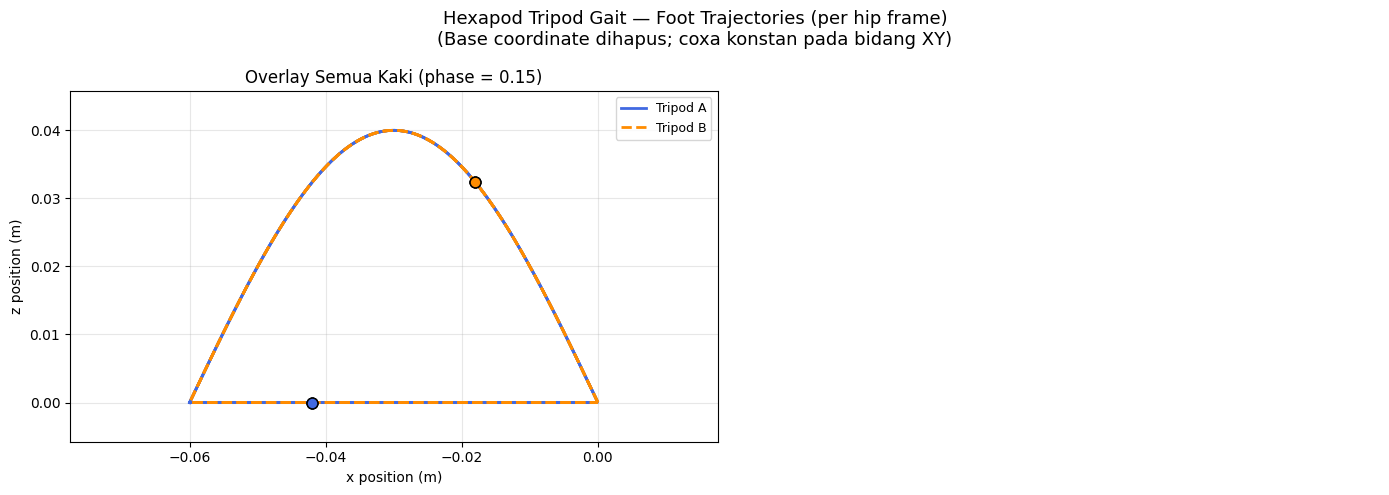

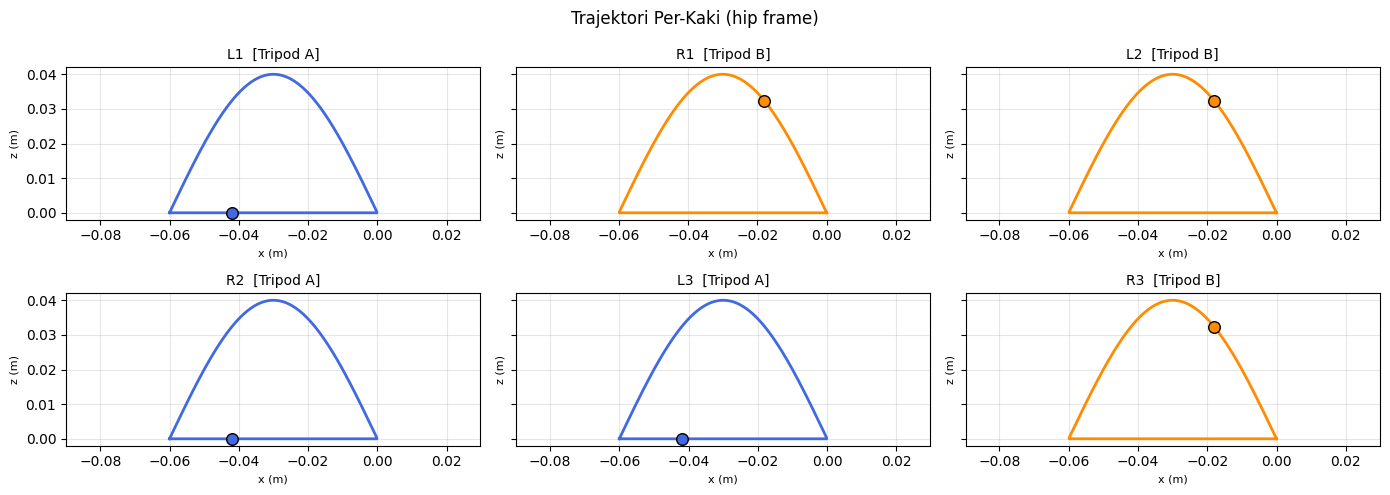


[INFO] Trajektori dihitung relatif terhadap hip masing-masing kaki.
[INFO] Base coordinate robot TIDAK disertakan dalam matriks posisi.
[INFO] Coxa setiap kaki beroperasi konstan pada bidang XY (tidak ikut swing/stance).


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """
    Menghitung posisi (x, z) end-effector kaki berdasarkan fase gait.
    Posisi relatif terhadap hip kaki masing-masing (base coordinate dihapus).
    """
    if phase < beta:   # Stance phase
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:              # Swing phase
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# Parameter Gait 
beta          = 0.5    
T             = 1.0    
x_stance      = -0.06  
x_lift        = 0.0    
z_ground      = 0.0    
z_clearance   = 0.04   
phase_show    = 0.15   

# Definisi Kaki & Offset 

hexapod_legs = {
    'L1': {'offset': 0.0, 'color': 'royalblue',   'group': 'Tripod A'},
    'R2': {'offset': 0.0, 'color': 'royalblue',   'group': 'Tripod A'},
    'L3': {'offset': 0.0, 'color': 'royalblue',   'group': 'Tripod A'},
    'R1': {'offset': 0.5, 'color': 'darkorange',  'group': 'Tripod B'},
    'L2': {'offset': 0.5, 'color': 'darkorange',  'group': 'Tripod B'},
    'R3': {'offset': 0.5, 'color': 'darkorange',  'group': 'Tripod B'},
}

t_arr    = np.linspace(0, T, 500)
phases_t = t_arr / T  # 0 → 1

# Plot Trajektori Semua Kaki
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hexapod Tripod Gait — Foot Trajectories (per hip frame)\n'
             '(Base coordinate dihapus; coxa konstan pada bidang XY)',
             fontsize=13)

# Panel kiri: overlay semua kaki
ax = axes[0]
plotted_groups = set()
for leg, info in hexapod_legs.items():
    xs, zs = [], []
    for ph in phases_t:
        x, z = foot_position_cmd((ph + info['offset']) % 1.0,
                                 beta, x_stance, x_lift, z_ground, z_clearance)
        xs.append(x); zs.append(z)

    label = info['group'] if info['group'] not in plotted_groups else None
    ax.plot(xs, zs, color=info['color'], linewidth=2, label=label,
            linestyle='-' if info['group'] == 'Tripod A' else '--')
    plotted_groups.add(info['group'])

    # Posisi sesaat
    ph_now = (phase_show + info['offset']) % 1.0
    x_now, z_now = foot_position_cmd(ph_now, beta, x_stance, x_lift,
                                     z_ground, z_clearance)
    ax.scatter([x_now], [z_now], color=info['color'], s=60,
               zorder=5, edgecolors='k')

ax.set_xlabel('x position (m)')
ax.set_ylabel('z position (m)')
ax.set_title(f'Overlay Semua Kaki (phase = {phase_show})')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.axis('equal')

# Panel kanan: 6 subplot kaki individual
ax2 = axes[1]
ax2.axis('off')
fig2, axs = plt.subplots(2, 3, figsize=(14, 5), sharey=True)
fig2.suptitle('Trajektori Per-Kaki (hip frame)', fontsize=12)

leg_order = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3']
for idx, leg in enumerate(leg_order):
    info  = hexapod_legs[leg]
    row, col = divmod(idx, 3)
    a = axs[row][col]
    xs, zs = [], []
    for ph in phases_t:
        x, z = foot_position_cmd((ph + info['offset']) % 1.0,
                                 beta, x_stance, x_lift, z_ground, z_clearance)
        xs.append(x); zs.append(z)

    a.plot(xs, zs, color=info['color'], linewidth=2)
    ph_now = (phase_show + info['offset']) % 1.0
    x_now, z_now = foot_position_cmd(ph_now, beta, x_stance, x_lift,
                                     z_ground, z_clearance)
    a.scatter([x_now], [z_now], color=info['color'], s=70,
              zorder=5, edgecolors='k')
    a.set_title(f'{leg}  [{info["group"]}]', fontsize=10)
    a.set_xlabel('x (m)', fontsize=8)
    a.set_ylabel('z (m)', fontsize=8)
    a.grid(True, alpha=0.3)
    a.axis('equal')

fig.tight_layout()
fig2.tight_layout()
plt.show()

print("\n[INFO] Trajektori dihitung relatif terhadap hip masing-masing kaki.")
print("[INFO] Base coordinate robot TIDAK disertakan dalam matriks posisi.")
print("[INFO] Coxa setiap kaki beroperasi konstan pada bidang XY (tidak ikut swing/stance).")


### 3. Analisis Stabilitas: Trot Quadruped vs. Tripod Hexapod

#### Trot Gait (Quadruped – 4 Kaki)

Pada *trot gait*, dua kaki diagonal bergerak secara bersamaan (misal FL+RR, lalu FR+RL).
Artinya, **hanya 2 kaki yang menyentuh tanah** pada satu waktu (duty factor β = 0,5).

- **Polygon pendukung:** Garis lurus antara dua titik kontak → **tidak membentuk area**.
- **Static Stability Margin (SSM):** SSM = 0; robot **tidak stabil secara statis**.
- Robot bergantung pada *dynamic stability* (momentum/inersia) untuk tidak jatuh.
- Kecepatan lebih tinggi karena fase swing lebih singkat.
- **Risiko:** Rentan jatuh pada terrain tidak rata atau saat berhenti mendadak.

#### Tripod Gait (Hexapod – 6 Kaki)

Pada *tripod gait*, 6 kaki dibagi menjadi dua kelompok segitiga bergantian:
- **Tripod A:** L1, R2, L3
- **Tripod B:** R1, L2, R3

Dengan β = 0,5, selalu tepat **3 kaki di tanah** setiap saat.

- **Polygon pendukung:** Segitiga dengan tiga titik kontak → **area dua dimensi yang terdefinisi**.
- **Static Stability Margin (SSM):** SSM > 0 selama pusat massa (CoM) berada di dalam segitiga pendukung.
- Robot **100% stabil secara statis** — dapat berhenti kapan saja tanpa jatuh.
- Lebih lambat dari trot quadruped, tetapi jauh lebih andal di medan tidak rata.

#### Kesimpulan Komparatif

| Aspek | Trot Quadruped | Tripod Hexapod |
|---|---|---|
| Kaki di tanah | 2 (50%) | 3 (50%) |
| Jenis stabilitas | Dinamis | Statis |
| Static Stability Margin | 0 (tidak ada) | > 0 (ada area) |
| Kecepatan gerak | Lebih cepat | Lebih lambat |
| Ketahanan terrain | Sedang | Tinggi |
| Fault tolerance | Rendah | Tinggi (dapat kehilangan 1 kaki) |

> **Catatan:** Tripod hexapod unggul secara stabilitas karena selalu memiliki fondasi segitiga yang solid.
> Ini menjadikannya pilihan utama untuk robot eksplorasi (rover) di terrain kompleks seperti permukaan berbatu atau tidak rata.
